In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Find project root
root = Path.cwd()
for _ in range(6):
    if (root / "data").exists() and (root / "src").exists():
        break
    root = root.parent

fp = root / "data" / "raw" / "tfe_deaths_weather_weekly_2016_2025_C429I.csv"
print("CWD:", os.getcwd())
print("File exists?", fp.exists(), fp)

# define output dirs
for _ in range(6):
    if (root/"data").exists() and (root/"src").exists():
        break
    root = root.parent

FIG_DIR = root / "reports" / "figures" / "eda01"
FIG_DIR.mkdir(parents=True, exist_ok=True)
# dirs for tables
TAB_DIR = root / "reports" / "tables" / "eda01"
TAB_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(fp)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").reset_index(drop=True)

df.head()

CWD: C:\dev\projects\heat_mortality_analysis\notebooks
File exists? True C:\dev\projects\heat_mortality_analysis\data\raw\tfe_deaths_weather_weekly_2016_2025_C429I.csv


,week_start,deaths_week,tmed_mean,tmax_mean,tmax_max,tmin_mean,tmin_min,prec_sum,hr_mean,presmax_mean,presmin_mean,wind_mean,gust_max,sun_sum,n_days,coverage
0,2016-01-04,155,19.100000,23.342857,24.1,14.828571,12.5,0.0,65.428571,1015.057143,1011.428571,4.385714,16.1,51.1,7,1.0
1,2016-01-11,189,21.642857,26.042857,29.3,17.242857,14.8,0.0,57.571429,1013.600000,1010.242857,5.128571,12.8,55.1,7,1.0
2,2016-01-18,175,20.100000,24.071429,25.4,16.157143,14.2,0.0,63.285714,1016.485714,1013.100000,5.242857,13.3,63.0,7,1.0
3,2016-01-25,137,20.628571,24.671429,27.2,16.614286,15.1,0.0,53.571429,1020.442857,1017.185714,9.100000,21.1,61.3,7,1.0
4,2016-02-01,146,20.228571,24.328571,26.7,16.128571,15.1,0.0,64.857143,1018.114286,1014.385714,6.528571,15.3,49.4,7,1.0


### Se detectan semanas con anomalías físicamente implausibles (p.ej. 2018-02-05), que requieren QA de unidades/coverage antes de inferir mecanismos.

In [3]:
qa = df.copy()

bad = (
    (qa["tmax_mean"] < qa["tmin_mean"]) |
    (qa["hr_mean"] < 0) | (qa["hr_mean"] > 100) |
    (qa["presmax_mean"] < 900) | (qa["presmax_mean"] > 1100) |
    (qa["presmin_mean"] < 900) | (qa["presmin_mean"] > 1100) |
    (qa["gust_max"] > 80)
)

bad_weeks = qa.loc[bad, ["week_start","coverage","n_days","tmed_mean","tmax_mean","tmin_mean",
                        "hr_mean","presmax_mean","presmin_mean","wind_mean","gust_max","sun_sum"]].sort_values("week_start")

df_clean = qa.loc[~bad].copy()

print("kept:", len(df_clean), "dropped:", bad.sum())
bad_weeks.head(20)

kept: 507 dropped: 14


,week_start,coverage,n_days,tmed_mean,tmax_mean,tmin_mean,hr_mean,presmax_mean,presmin_mean,wind_mean,gust_max,sun_sum
28,2016-07-18,1.0,7,25.766667,30.533333,20.983333,8.200000,11.060000,0.000000,82.600000,NaN,10.3
29,2016-07-25,1.0,7,26.071429,30.500000,21.585714,33.142857,439.157143,754.425000,52.757143,18.6,32.2
108,2018-01-29,1.0,7,4.642857,10.942857,11.550000,27.700000,297.857143,1007.100000,6.614286,1014.3,5058.2
109,2018-02-05,1.0,7,5.028571,10.000000,13.700000,32.442857,298.085714,1014.150000,7.671429,1018.5,5073.0
152,2018-12-03,1.0,7,22.157143,26.842857,17.428571,368.483333,676.783333,676.550000,39.657143,14.4,35.7
153,2018-12-10,1.0,7,20.057143,23.885714,16.242857,1017.714286,20.285714,13.128571,79.285714,NaN,0.0
235,2020-07-06,1.0,7,24.714286,28.842857,20.600000,60.142857,436.942857,478.057143,9.000000,1008.6,4048.9
236,2020-07-13,1.0,7,25.028571,29.471429,20.571429,50.857143,154.828571,217.485714,10.928571,1010.1,6036.1
361,2022-12-05,1.0,7,21.757143,24.642857,18.857143,61.500000,1008.600000,290.885714,10.985714,18.6,5055.7
362,2022-12-12,1.0,7,20.628571,24.314286,16.971429,69.000000,506.600000,298.028571,7.085714,9.7,5068.3


In [4]:
print(df_clean.shape)
print(df_clean["week_start"].min(), "→", df_clean["week_start"].max())
df_clean.isna().mean().sort_values(ascending=False).head(20)

(507, 16)
2016-01-04 00:00:00 → 2025-12-22 00:00:00


week_start      0.0
deaths_week     0.0
tmed_mean       0.0
tmax_mean       0.0
tmax_max        0.0
tmin_mean       0.0
tmin_min        0.0
prec_sum        0.0
hr_mean         0.0
presmax_mean    0.0
presmin_mean    0.0
wind_mean       0.0
gust_max        0.0
sun_sum         0.0
n_days          0.0
coverage        0.0
dtype: float64

In [5]:
target = "deaths_week"

df_clean["weekofyear"] = df_clean["week_start"].dt.isocalendar().week.astype(int)
df_clean["deaths_season_mean"] = df_clean.groupby("weekofyear")[target].transform("mean")
df_clean["deaths_excess"] = df_clean[target] - df_clean["deaths_season_mean"]
df_clean["deaths_excess_roll3"] = df_clean["deaths_excess"].rolling(3, center=True).mean()

df_clean["year"] = df_clean["week_start"].dt.year
df_clean["deaths_excess_year_centered"] = df_clean["deaths_excess"] - df_clean.groupby("year")["deaths_excess"].transform("mean")

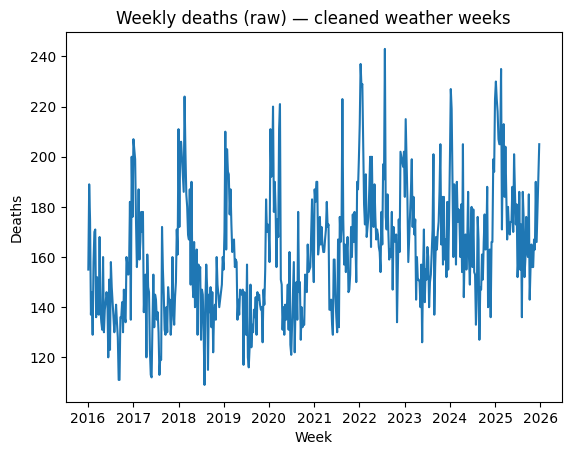

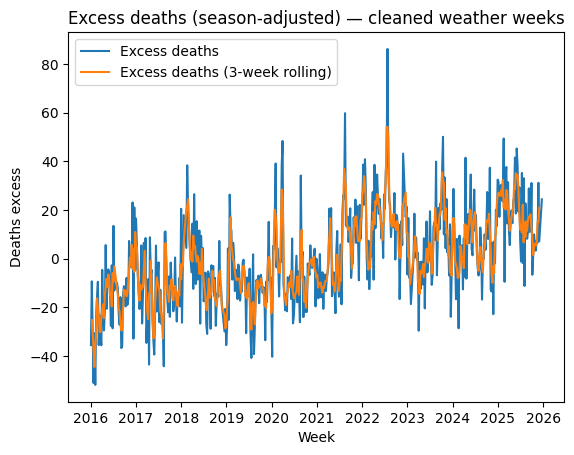

In [6]:
plt.figure()
plt.plot(df_clean["week_start"], df_clean[target])
plt.title("Weekly deaths (raw) — cleaned weather weeks")
plt.xlabel("Week"); plt.ylabel("Deaths")
plt.savefig(FIG_DIR / "01_weekly_death_weather_cleaned.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_clean["week_start"], df_clean["deaths_excess"], label="Excess deaths")
plt.plot(df_clean["week_start"], df_clean["deaths_excess_roll3"], label="Excess deaths (3-week rolling)")
plt.title("Excess deaths (season-adjusted) — cleaned weather weeks")
plt.xlabel("Week"); plt.ylabel("Deaths excess")
plt.savefig(FIG_DIR / "02_excess_deaths_timeseries.png", dpi=200, bbox_inches="tight")
plt.legend()
plt.show()

In [7]:
top_hi = df_clean.nlargest(10, "deaths_excess_year_centered")[["week_start", target, "deaths_excess", "deaths_excess_year_centered"]]
top_lo = df_clean.nsmallest(10, "deaths_excess_year_centered")[["week_start", target, "deaths_excess", "deaths_excess_year_centered"]]

top_hi, top_lo

(    week_start  deaths_week  deaths_excess  deaths_excess_year_centered
 342 2022-07-25          243      86.222222                    67.998722
 293 2021-08-16          223      59.800000                    57.137637
 221 2020-03-30          221      48.400000                    53.023921
 406 2023-10-16          205      50.100000                    45.082532
 111 2018-02-19          224      38.400000                    43.987415
 213 2020-02-03          220      39.125000                    43.748921
 220 2020-03-23          211      38.400000                    43.023921
 48  2016-12-05          182      23.125000                    39.585587
 242 2020-08-24          178      34.200000                    38.823921
 50  2016-12-19          200      21.111111                    37.571698,
     week_start  deaths_week  deaths_excess  deaths_excess_year_centered
 209 2020-01-06          158     -40.300000                   -35.676079
 5   2016-02-08          129     -51.875000       

In [8]:
climate_vars = [
    "tmed_mean","tmax_mean","tmax_max","tmin_mean","tmin_min",
    "prec_sum","hr_mean","presmax_mean","presmin_mean","wind_mean","gust_max","sun_sum"
]

corr = df_clean[climate_vars + ["deaths_excess"]].corr(numeric_only=True)["deaths_excess"].sort_values(ascending=False)
corr

deaths_excess    1.000000
prec_sum         0.128589
tmin_mean        0.052264
tmed_mean        0.051494
tmax_mean        0.049061
tmax_max         0.047447
tmin_min         0.037515
sun_sum          0.035015
hr_mean         -0.011864
gust_max        -0.013668
wind_mean       -0.020146
presmax_mean    -0.132777
presmin_mean    -0.144780
Name: deaths_excess, dtype: float64

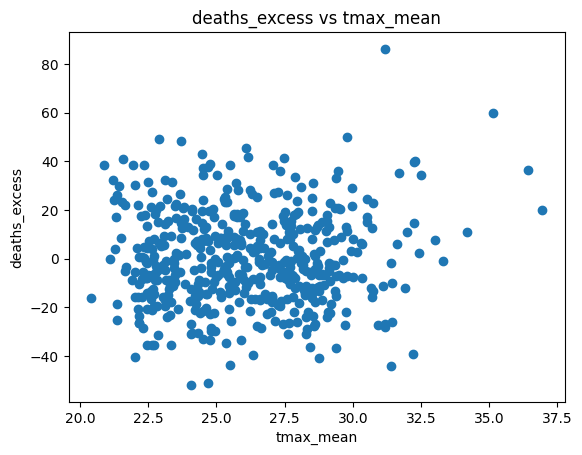

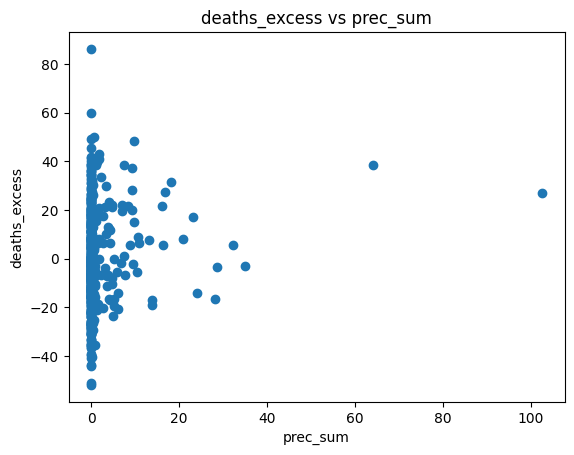

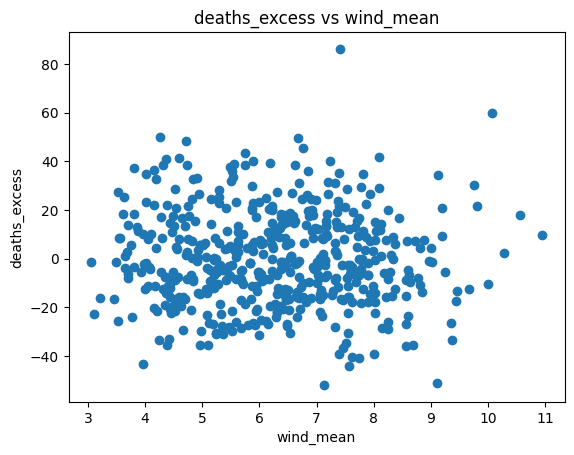

In [9]:
pairs = ["tmax_mean", "prec_sum", "wind_mean"]

for x in pairs:
    plt.figure()
    plt.scatter(df_clean[x], df_clean["deaths_excess"])
    plt.title(f"deaths_excess vs {x}")
    plt.xlabel(x)
    plt.ylabel("deaths_excess")
    plt.savefig(FIG_DIR / f"excess_deaths_vs_{x}_scatter.png", dpi=200, bbox_inches="tight")
    plt.show()

In [10]:
for k in [0,1,2]:
    df_clean[f"tmax_mean_lag{k}"] = df_clean["tmax_mean"].shift(k)

for k in [0,1,2]:
    c = df_clean[["deaths_excess", f"tmax_mean_lag{k}"]].corr().iloc[0,1]
    print("corr(deaths_excess, tmax_mean lag", k, "):", c)

corr(deaths_excess, tmax_mean lag 0 ): 0.049061101341841544
corr(deaths_excess, tmax_mean lag 1 ): -0.01160537477514013
corr(deaths_excess, tmax_mean lag 2 ): 0.007445974292550262


“Al ajustar por estacionalidad, los mayores picos de exceso se concentran en 2020–2023.”

“Varios picos de verano coinciden con anomalías positivas de temperatura (p.ej. +4.1°C en tmax_mean en 2021-08-16).”

“Los picos de marzo 2020 NO coinciden con calor, lo que sugiere un shock no climático (probablemente COVID).”

“Se detectan semanas con anomalías físicamente implausibles (p.ej. 2018-02-05), que requieren QA de unidades/coverage antes de inferir mecanismos.”

In [11]:
q95 = df_clean["tmax_mean"].quantile(0.95)
q99 = df_clean["tmax_mean"].quantile(0.99)

df_clean["heat_p95"] = (df_clean["tmax_mean"] >= q95).astype(int)
df_clean["heat_p99"] = (df_clean["tmax_mean"] >= q99).astype(int)

df_clean.groupby("heat_p95")["deaths_excess"].agg(["count","mean","median","std"]), q95

(          count      mean    median        std
 heat_p95                                      
 0           481 -0.416055 -1.900000  18.489862
 1            26  7.697009  6.844444  31.430722,
 np.float64(30.72857142857143))

In [12]:
df_clean.groupby("heat_p99")["deaths_excess"].agg(["count","mean","median","std"]), q99

(          count       mean     median        std
 heat_p99                                        
 0           501  -0.267443  -1.857143  19.230026
 1             6  22.331481  15.550000  22.342400,
 np.float64(32.98342857142857))

<Figure size 640x480 with 0 Axes>

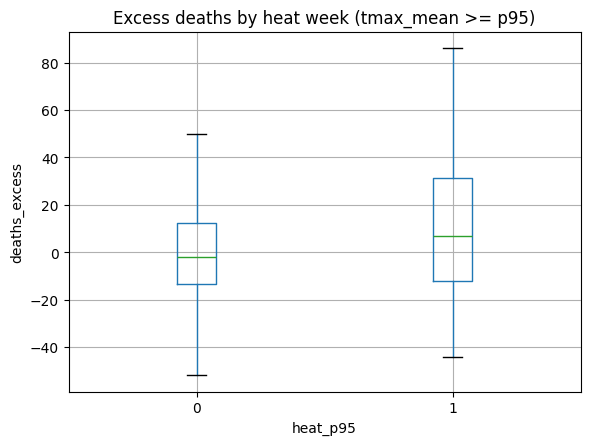

In [13]:
plt.figure()
df_clean.boxplot(column="deaths_excess", by="heat_p95")
plt.title("Excess deaths by heat week (tmax_mean >= p95)")
plt.suptitle("")
plt.xlabel("heat_p95")
plt.ylabel("deaths_excess")
plt.savefig(FIG_DIR / "06_excess_deaths_by_heat_week_p95.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
q95x = df_clean["tmax_max"].quantile(0.95)
df_clean["heatmax_p95"] = (df_clean["tmax_max"] >= q95x).astype(int)
df_clean.groupby("heatmax_p95")["deaths_excess"].agg(["count","mean","median","std"]), q95x

(             count      mean    median        std
 heatmax_p95                                      
 0              481 -0.168191 -1.857143  19.017883
 1               26  3.111538  2.650000  25.728727,
 np.float64(35.67))

In [15]:
# anomalía estacional de tmax_mean (quita estacionalidad)
df_clean["tmax_anom"] = df_clean["tmax_mean"] - df_clean.groupby("weekofyear")["tmax_mean"].transform("mean")

q95a = df_clean["tmax_anom"].quantile(0.95)
q99a = df_clean["tmax_anom"].quantile(0.99)

df_clean["heat_anom_p95"] = (df_clean["tmax_anom"] >= q95a).astype(int)
df_clean["heat_anom_p99"] = (df_clean["tmax_anom"] >= q99a).astype(int)

df_clean.groupby("heat_anom_p95")["deaths_excess"].agg(["count","mean","median","std"]), q95a

(               count      mean    median        std
 heat_anom_p95                                      
 0                481 -0.393913 -1.857143  19.270906
 1                 26  7.287393 -0.805556  20.696779,
 np.float64(2.4946190476190493))

In [16]:
df_clean.groupby("heat_anom_p99")["deaths_excess"].agg(["count","mean","median","std"]), q99a

#export tables
top_hi.to_csv(TAB_DIR / "top_peaks_excess_year_centered.csv", index=False)
bad_weeks.to_csv(TAB_DIR / "qa_bad_weeks_weather.csv", index=False)
heat_p95_summary = df_clean.groupby("heat_p95")["deaths_excess"].agg(["count","mean","median","std"])
heat_p95_summary.to_csv(TAB_DIR / "heat_p95_summary.csv")

heat_p99_summary = df_clean.groupby("heat_p99")["deaths_excess"].agg(["count","mean","median","std"])
heat_p99_summary.to_csv(TAB_DIR / "heat_p99_summary.csv")

# Key findings (climate-only, weekly, 2016–2025):

* After removing 14/521 weeks with physically implausible weather values, the season-adjusted mortality signal remains stable.

* Linear correlations between weekly excess deaths and temperature are near zero, suggesting a non-linear relationship.

* Heat weeks defined by absolute temperature show higher excess deaths:

* tmax_mean ≥ p95 (~30.7°C): mean excess ≈ +7.7 deaths/week (n=26)

* tmax_mean ≥ p99 (~33.0°C): mean excess ≈ +22.3 deaths/week (n=6)

* Heat anomalies relative to the seasonal baseline also show elevated excess deaths, especially at the extreme tail (p99), but with smaller sample sizes and higher uncertainty.

## Next steps:

In Notebook 02, test whether dust/PM and CAP alerts explain additional variance and whether they confound or amplify heat-related excess mortality (including lag structures).

<Figure size 640x480 with 0 Axes>

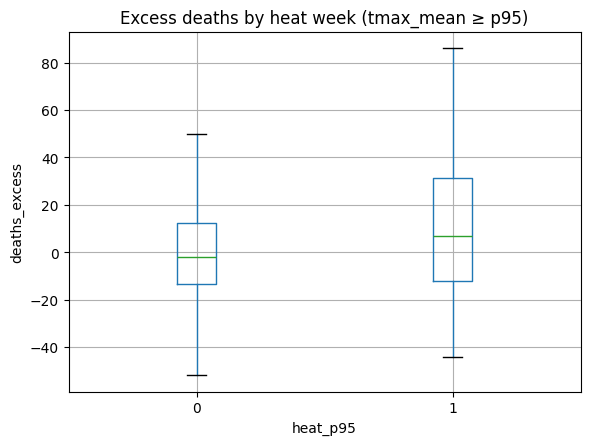

<Figure size 640x480 with 0 Axes>

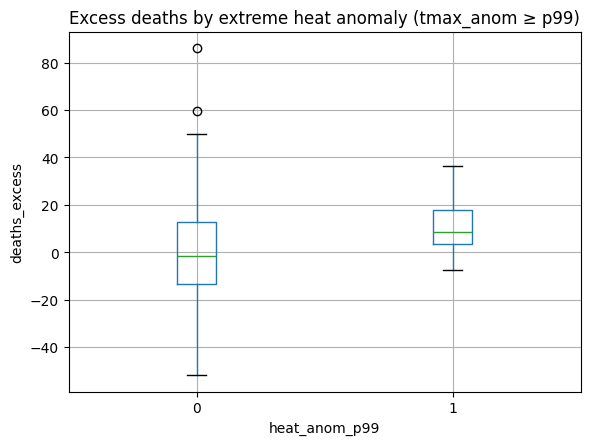

In [17]:
plt.figure()
df_clean.boxplot(column="deaths_excess", by="heat_p95")
plt.title("Excess deaths by heat week (tmax_mean ≥ p95)")
plt.suptitle("")
plt.xlabel("heat_p95")
plt.ylabel("deaths_excess")

plt.show()

plt.figure()
df_clean.boxplot(column="deaths_excess", by="heat_anom_p99")
plt.title("Excess deaths by extreme heat anomaly (tmax_anom ≥ p99)")
plt.suptitle("")
plt.xlabel("heat_anom_p99")
plt.ylabel("deaths_excess")
plt.savefig(FIG_DIR / "08_excess_deaths_by_heat_p95.png", dpi=200, bbox_inches="tight")
plt.show()